In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
fig_size = (12, 8)

# Load the benchmark data
aggregation_data = pd.read_csv('aggregation_queries_benchmark_updated.csv')
standard_data = pd.read_csv('standard_queries_benchmark_updated.csv')

print("Aggregation Queries Data Shape:", aggregation_data.shape)
print("Standard Queries Data Shape:", standard_data.shape)
print("\nColumns:", list(aggregation_data.columns))

Aggregation Queries Data Shape: (10, 8)
Standard Queries Data Shape: (10, 8)

Columns: ['Number_of_threads', 'Un-sharded_collection', '2_shards_collection', '4_shards_collection', '6_shards_collection', 'Queries_hitting_single_shard', '3_shards_collection', '5_shards_collection']


In [24]:
# Display basic statistics
print("\n=== STANDARD QUERIES BENCHMARK ===")
print(standard_data.head())
print("\nDescriptive Statistics:")
print(standard_data.describe())

print("=== AGGREGATION QUERIES BENCHMARK ===")
print(aggregation_data.head())
print("\nDescriptive Statistics:")
print(aggregation_data.describe())

# Create a mapping for better column names
shard_columns = {
    'Un-sharded_collection': '1 Shard',
    '2_shards_collection': '2 Shards',
    '3_shards_collection': '3 Shards',
    '4_shards_collection': '4 Shards',
    '5_shards_collection': '5 Shards',
    '6_shards_collection': '6 Shards',
    'Queries_hitting_single_shard': 'Single Shard Hit'
}


=== STANDARD QUERIES BENCHMARK ===
   Number_of_threads  Un-sharded_collection  2_shards_collection  \
0                  1                     30                   19   
1                  2                     41                   25   
2                  3                     45                   40   
3                  4                     62                   60   
4                  6                    157                  114   

   4_shards_collection  6_shards_collection  Queries_hitting_single_shard  \
0                   14                   14                             7   
1                   20                   18                             6   
2                   33                   30                             6   
3                   49                   45                             7   
4                   84                   74                            10   

   3_shards_collection  5_shards_collection  
0                 16.5                 14.0  


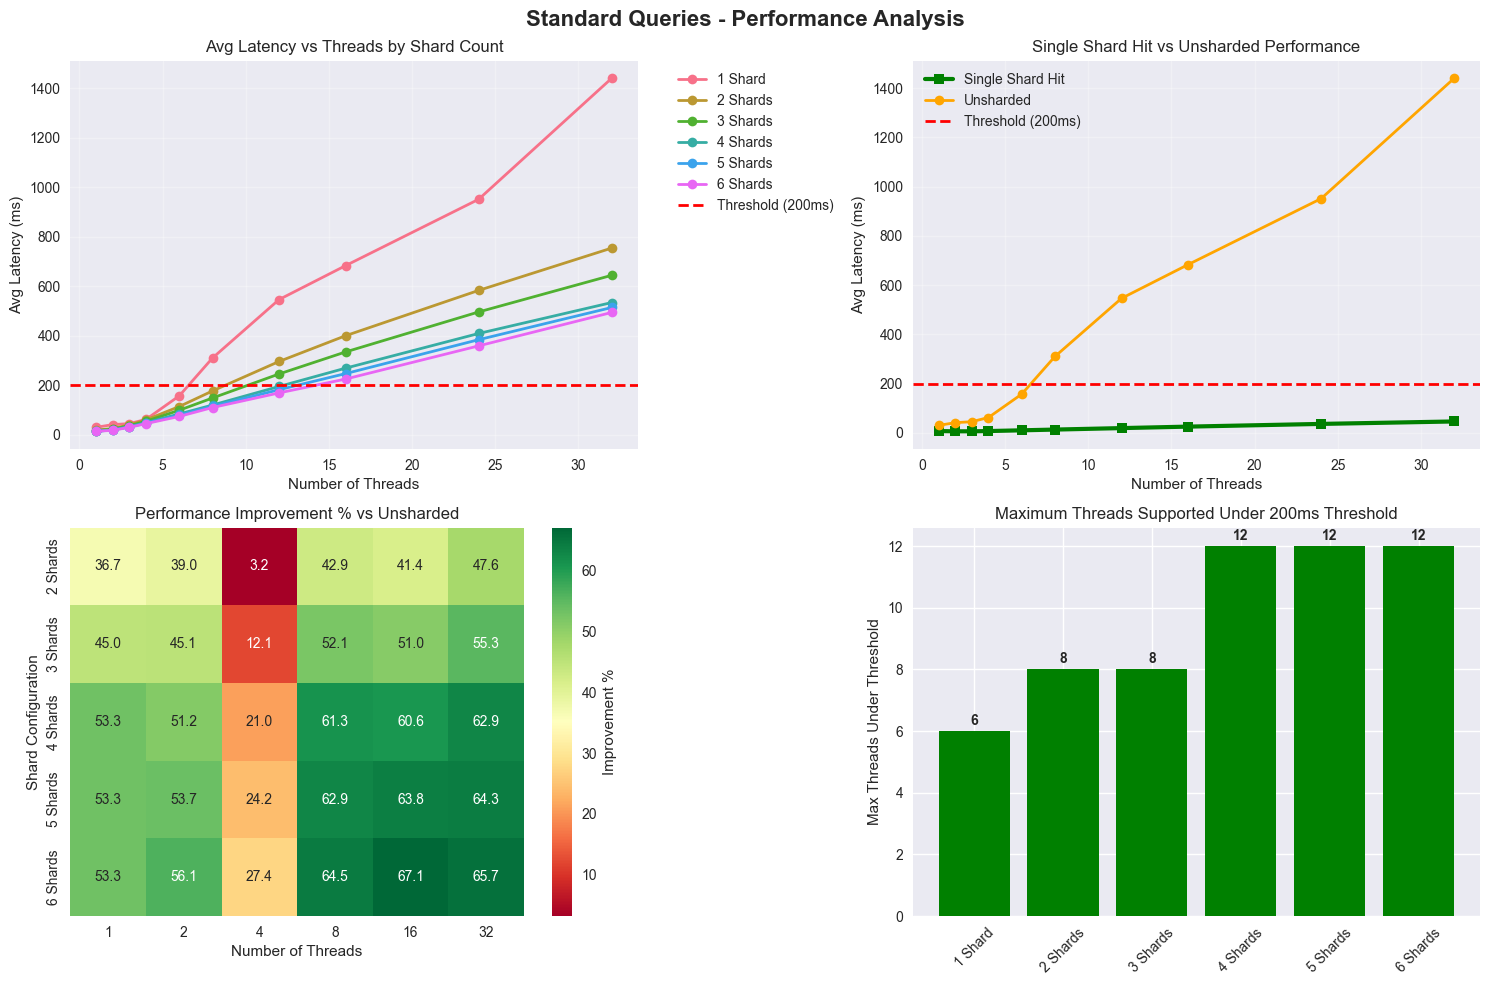

In [25]:
def plot_performance_analysis(data, title, threshold, fig_size=(15, 10)):
   """Plot comprehensive performance analysis for the given dataset"""
   
   fig, axes = plt.subplots(2, 2, figsize=fig_size)
   fig.suptitle(f'{title} - Performance Analysis', fontsize=16, fontweight='bold')
   
   # 1. Latency vs Threads for different shard configurations
   ax1 = axes[0, 0]
   for col in ['Un-sharded_collection', '2_shards_collection', '3_shards_collection', 
               '4_shards_collection', '5_shards_collection', '6_shards_collection']:
       ax1.plot(data['Number_of_threads'], data[col], marker='o', linewidth=2, 
               label=shard_columns[col])
   
   ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold ({threshold}ms)')
   ax1.set_xlabel('Number of Threads')
   ax1.set_ylabel('Avg Latency (ms)')
   ax1.set_title('Avg Latency vs Threads by Shard Count')
   ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
   ax1.grid(True, alpha=0.3)
   
   # 2. Single shard hit performance comparison
   ax2 = axes[0, 1]
   ax2.plot(data['Number_of_threads'], data['Queries_hitting_single_shard'], 
            marker='s', color='green', linewidth=3, label='Single Shard Hit')
   ax2.plot(data['Number_of_threads'], data['Un-sharded_collection'], 
            marker='o', color='orange', linewidth=2, label='Unsharded')
   ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold ({threshold}ms)')
   ax2.set_xlabel('Number of Threads')
   ax2.set_ylabel('Avg Latency (ms)')
   ax2.set_title('Single Shard Hit vs Unsharded Performance')
   ax2.legend()
   ax2.grid(True, alpha=0.3)
   
   # 3. Performance improvement by sharding (filtered to original thread counts)
   ax3 = axes[1, 0]
   improvement_data = []
   shard_configs = ['2_shards_collection', '3_shards_collection', '4_shards_collection', 
                    '5_shards_collection', '6_shards_collection']
   
   # Filter to only original thread counts
   original_threads = [1, 2, 4, 8, 16, 32]
   filtered_data = data[data['Number_of_threads'].isin(original_threads)]
   
   for threads in filtered_data['Number_of_threads']:
       row_data = filtered_data[filtered_data['Number_of_threads'] == threads].iloc[0]
       baseline = row_data['Un-sharded_collection']
       improvements = []
       for config in shard_configs:
           improvement = ((baseline - row_data[config]) / baseline) * 100
           improvements.append(improvement)
       improvement_data.append(improvements)
   
   improvement_df = pd.DataFrame(improvement_data, 
                                 columns=['2 Shards', '3 Shards', '4 Shards', '5 Shards', '6 Shards'],
                                 index=filtered_data['Number_of_threads'])
   
   sns.heatmap(improvement_df.T, annot=True, fmt='.1f', cmap='RdYlGn', 
               ax=ax3, cbar_kws={'label': 'Improvement %'})
   ax3.set_title('Performance Improvement % vs Unsharded')
   ax3.set_xlabel('Number of Threads')
   ax3.set_ylabel('Shard Configuration')
   
   # 4. Threshold compliance analysis
   ax4 = axes[1, 1]
   compliance_data = []
   
   for config in ['Un-sharded_collection', '2_shards_collection', '3_shards_collection',
                  '4_shards_collection', '5_shards_collection', '6_shards_collection']:
       compliant_threads = data[data[config] <= threshold]['Number_of_threads'].max()
       if pd.isna(compliant_threads):
           compliant_threads = 0
       compliance_data.append(compliant_threads)
   
   config_names = ['1 Shard', '2 Shards', '3 Shards', '4 Shards', '5 Shards', '6 Shards']
   bars = ax4.bar(config_names, compliance_data, color=['red' if x == 0 else 'green' for x in compliance_data])
   ax4.set_ylabel('Max Threads Under Threshold')
   ax4.set_title(f'Maximum Threads Supported Under {threshold}ms Threshold')
   ax4.tick_params(axis='x', rotation=45)
   
   # Add value labels on bars
   for bar, value in zip(bars, compliance_data):
       if value > 0:
           ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    str(int(value)), ha='center', va='bottom', fontweight='bold')
   
   plt.tight_layout()
   plt.show()

# Plot aggregation queries analysis
plot_performance_analysis(standard_data, 'Standard Queries', 200)

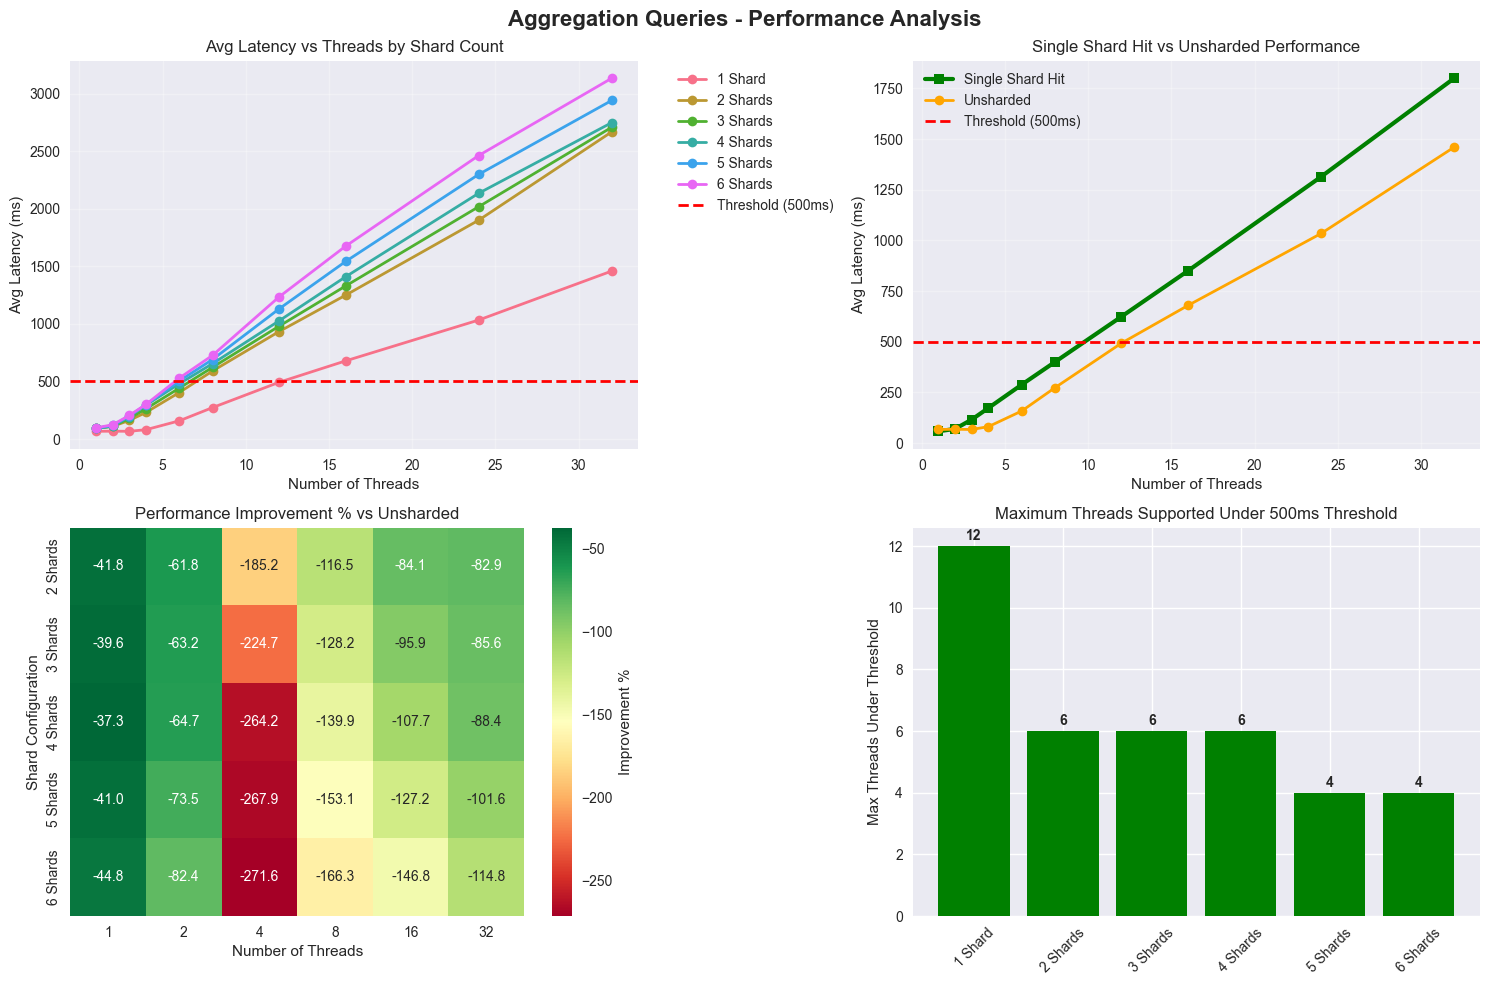

In [26]:
plot_performance_analysis(aggregation_data, 'Aggregation Queries', 500)

In [27]:
def find_optimal_sharding_strategy(data, threshold, query_type):
   """
   Find the minimum number of shards needed to stay under the threshold
   for different thread ranges.
   """
   print(f"\n=== OPTIMAL SHARDING STRATEGY FOR {query_type.upper()} ===")
   print(f"Threshold: {threshold}ms\n")
   
   # Define shard configurations in order
   shard_configs = [
       ('Un-sharded_collection', 1),
       ('2_shards_collection', 2),
       ('3_shards_collection', 3),
       ('4_shards_collection', 4),
       ('5_shards_collection', 5),
       ('6_shards_collection', 6)
   ]
   
   # Interpolate data for missing thread counts (1-32)
   from scipy.interpolate import interp1d
   
   interpolated_data = []
   all_threads = list(range(1, 33))  # 1 to 32 threads
   
   for threads in all_threads:
       if threads in data['Number_of_threads'].values:
           # Use actual data
           row = data[data['Number_of_threads'] == threads].iloc[0]
           interpolated_data.append(row.to_dict())
       else:
           # Interpolate missing values
           interpolated_row = {'Number_of_threads': threads}
           
           for config_col, _ in shard_configs:
               # Create interpolation function for this configuration
               f = interp1d(data['Number_of_threads'], data[config_col], 
                          kind='linear', fill_value='extrapolate')
               interpolated_row[config_col] = float(f(threads))
           
           # Interpolate single shard hits
           f_single = interp1d(data['Number_of_threads'], data['Queries_hitting_single_shard'], 
                             kind='linear', fill_value='extrapolate')
           interpolated_row['Queries_hitting_single_shard'] = float(f_single(threads))
           
           interpolated_data.append(interpolated_row)
   
   # Convert to DataFrame
   interpolated_df = pd.DataFrame(interpolated_data)
   
   # Find maximum threads that 6 shards can support under threshold
   max_threads_6shards = interpolated_df[interpolated_df['6_shards_collection'] <= threshold]['Number_of_threads'].max()
   if pd.isna(max_threads_6shards):
       max_threads_6shards = 0
   
   # Find optimal configuration for each thread count
   recommendations = []
   
   for _, row in interpolated_df.iterrows():
       threads = int(row['Number_of_threads'])
       optimal_shards = None
       optimal_latency = float('inf')
       
       # Check each shard configuration
       for config_col, shard_count in shard_configs:
           latency = row[config_col]
           if latency <= threshold:
               if optimal_shards is None or shard_count < optimal_shards:
                   optimal_shards = shard_count
                   optimal_latency = latency
       
       if optimal_shards is None:
           # No configuration meets the threshold
           # Find the best performing one
           best_latency = float('inf')
           best_shards = 6  # Default to maximum shards
           for config_col, shard_count in shard_configs:
               if row[config_col] < best_latency:
                   best_latency = row[config_col]
                   best_shards = shard_count
           
           # For threads beyond 6-shard capability, use 6+ notation
           if threads > max_threads_6shards:
               best_shards = "6+"
           
           recommendations.append({
               'threads': threads,
               'min_shards': best_shards,
               'latency': best_latency,
               'meets_threshold': False,
               'note': f'Exceeds threshold by {best_latency - threshold:.1f}ms'
           })
       else:
           recommendations.append({
               'threads': threads,
               'min_shards': optimal_shards,
               'latency': optimal_latency,
               'meets_threshold': True,
               'note': 'Within threshold'
           })
   
   # Group consecutive thread ranges with same shard requirements
   grouped_recommendations = []
   current_group = None
   
   for rec in recommendations:
       if current_group is None or current_group['min_shards'] != rec['min_shards']:
           if current_group is not None:
               grouped_recommendations.append(current_group)
           current_group = {
               'thread_range': [rec['threads']],
               'min_shards': rec['min_shards'], 
               'meets_threshold': rec['meets_threshold'],
               'avg_latency': rec['latency']
           }
       else:
           current_group['thread_range'].append(rec['threads'])
           current_group['avg_latency'] = (current_group['avg_latency'] + rec['latency']) / 2
   
   if current_group is not None:
       grouped_recommendations.append(current_group)
   
   # Print recommendations
   print("THREAD RANGE → MINIMUM SHARDS RECOMMENDATION")
   print("=" * 60)
   
   for group in grouped_recommendations:
       thread_range = group['thread_range']
       if len(thread_range) == 1:
           range_str = f"{thread_range[0]} threads"
       else:
           range_str = f"{thread_range[0]}-{thread_range[-1]} threads"
       
       status = "✓" if group['meets_threshold'] else "⚠"
       print(f"{range_str:15} → {group['min_shards']} shards {status} "
             f"(~{group['avg_latency']:.1f}ms avg)")
   
   print(f"\n✓ = Meets {threshold}ms threshold")
   print("⚠ = Exceeds threshold (best available option)")
   
   # Additional insights
   print(f"\n=== KEY INSIGHTS FOR {query_type.upper()} ===")
   
   # Single shard hit performance
   single_shard_performance = interpolated_df['Queries_hitting_single_shard'].max()
   print(f"• Single shard hit queries: Max {single_shard_performance:.1f}ms latency")
   if single_shard_performance <= threshold:
       print(f"  → Single shard hits ALWAYS meet the {threshold}ms threshold")
   else:
       print(f"  → Single shard hits exceed threshold at high thread counts")
   
   # Scalability analysis
   max_threads_unsharded = interpolated_df[interpolated_df['Un-sharded_collection'] <= threshold]['Number_of_threads'].max()
   
   if pd.notna(max_threads_unsharded):
       print(f"• Unsharded cluster supports up to {int(max_threads_unsharded)} threads under threshold")
   else:
       print("• Unsharded cluster exceeds threshold at all thread levels")
       
   if max_threads_6shards > 0:
       print(f"• 6-shard cluster supports up to {int(max_threads_6shards)} threads under threshold")
       if max_threads_6shards < 32:
           print(f"• {int(max_threads_6shards + 1)}-32 threads require 6+ shards (exceeds threshold)")
   else:
       print("• Even 6-shard cluster exceeds threshold at all thread levels")
   
   return recommendations

# Calculate optimal strategies
std_recommendations = find_optimal_sharding_strategy(standard_data, 200, "Standard Queries")
agg_recommendations = find_optimal_sharding_strategy(aggregation_data, 500, "Aggregation Queries")


=== OPTIMAL SHARDING STRATEGY FOR STANDARD QUERIES ===
Threshold: 200ms

THREAD RANGE → MINIMUM SHARDS RECOMMENDATION
1-6 threads     → 1 shards ✓ (~118.7ms avg)
7-8 threads     → 2 shards ✓ (~161.2ms avg)
9-10 threads    → 3 shards ✓ (~184.9ms avg)
11-12 threads   → 4 shards ✓ (~185.6ms avg)
13 threads      → 5 shards ✓ (~198.2ms avg)
14 threads      → 6 shards ✓ (~197.0ms avg)
15-32 threads   → 6+ shards ⚠ (~477.1ms avg)

✓ = Meets 200ms threshold
⚠ = Exceeds threshold (best available option)

=== KEY INSIGHTS FOR STANDARD QUERIES ===
• Single shard hit queries: Max 46.0ms latency
  → Single shard hits ALWAYS meet the 200ms threshold
• Unsharded cluster supports up to 6 threads under threshold
• 6-shard cluster supports up to 14 threads under threshold
• 15-32 threads require 6+ shards (exceeds threshold)

=== OPTIMAL SHARDING STRATEGY FOR AGGREGATION QUERIES ===
Threshold: 500ms

THREAD RANGE → MINIMUM SHARDS RECOMMENDATION
1-12 threads    → 1 shards ✓ (~438.3ms avg)
13-32 threads 

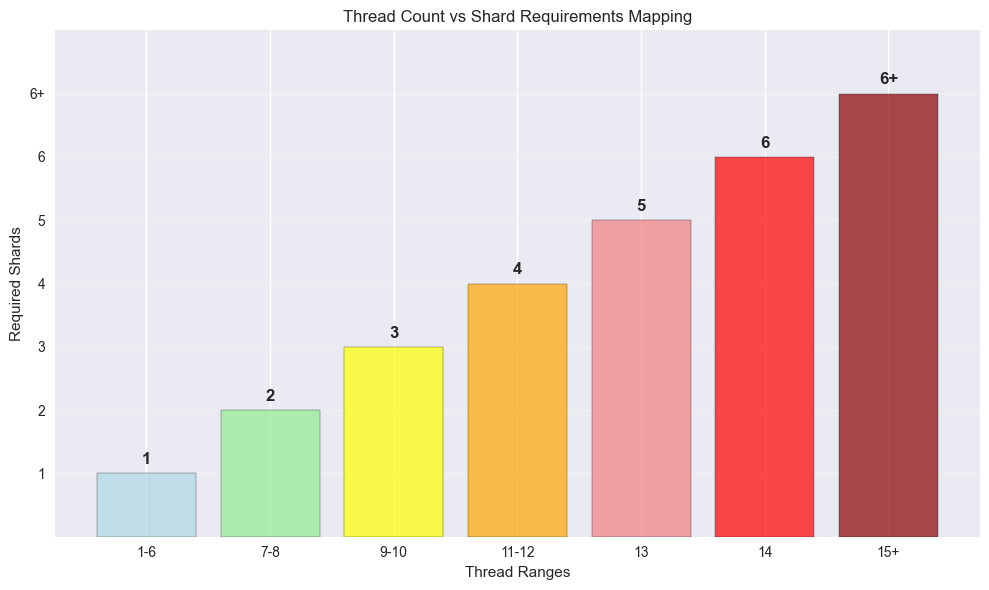

In [28]:
# Simple histogram plot showing thread ranges vs shard counts
def plot_thread_range_shard_mapping():
   """
   Simple histogram showing mapping between thread ranges and shard requirements
   """
   
   # Define the thread range data
   thread_ranges = [
       '1-6',
       '7-8', 
       '9-10',
       '11-12',
       '13',
       '14',
       '15+'
   ]
   
   shard_counts = [1, 2, 3, 4, 5, 6, 7]  # 7 represents 6+ shards
   
   # Create the plot
   fig, ax = plt.subplots(1, 1, figsize=(10, 6))
   
   # Create color gradient
   colors = ['lightblue', 'lightgreen', 'yellow', 'orange', 'lightcoral', 'red', 'darkred']
   
   # Create bars
   bars = ax.bar(thread_ranges, shard_counts, color=colors, alpha=0.7, edgecolor='black')
   
   # Customize the plot
   ax.set_xlabel('Thread Ranges')
   ax.set_ylabel('Required Shards')
   ax.set_title('Thread Count vs Shard Requirements Mapping')
   ax.grid(True, alpha=0.3, axis='y')
   
   # Set y-axis to show shard counts clearly
   ax.set_ylim(0, 8)
   ax.set_yticks(range(1, 8))
   ax.set_yticklabels(['1', '2', '3', '4', '5', '6', '6+'])
   
   # Add shard count labels on bars
   for bar, shards in zip(bars, shard_counts):
       shard_label = '6+' if shards == 7 else str(shards)
       ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
               shard_label, ha='center', va='bottom', fontweight='bold', fontsize=12)
   
   plt.tight_layout()
   plt.show()

# Create the simple mapping plot
plot_thread_range_shard_mapping()

In [29]:
def cost_benefit_analysis(agg_data, std_data):
    """
    Analyze the cost-benefit of different sharding strategies
    """
    print("\n=== COST-BENEFIT ANALYSIS ===\n")
    
    # Assume linear cost scaling with shards (you can adjust these factors)
    cost_per_shard = 1.0  # Relative cost unit
    
    shard_configs = [1, 2, 3, 4, 5, 6]
    
    analysis_results = []
    
    for shards in shard_configs:
        cost = shards * cost_per_shard
        
        if shards == 1:
            agg_col = 'Un-sharded_collection'
            std_col = 'Un-sharded_collection'
        else:
            agg_col = f'{shards}_shards_collection'
            std_col = f'{shards}_shards_collection'
        
        # Calculate average performance across all thread levels
        avg_agg_latency = agg_data[agg_col].mean()
        avg_std_latency = std_data[std_col].mean()
        
        # Calculate compliance rates
        agg_compliance = (agg_data[agg_col] <= 500).mean() * 100
        std_compliance = (std_data[std_col] <= 200).mean() * 100
        
        # Calculate performance score (lower latency = higher score)
        max_agg_latency = agg_data[agg_col].max()
        max_std_latency = std_data[std_col].max()
        
        analysis_results.append({
            'shards': shards,
            'cost': cost,
            'avg_agg_latency': avg_agg_latency,
            'avg_std_latency': avg_std_latency,
            'agg_compliance': agg_compliance,
            'std_compliance': std_compliance,
            'max_agg_latency': max_agg_latency,
            'max_std_latency': max_std_latency
        })
    
    results_df = pd.DataFrame(analysis_results)
    
    print("SHARDING CONFIGURATION COMPARISON")
    print("=" * 80)
    print(f"{'Shards':<8} {'Cost':<8} {'Avg Agg':<10} {'Avg Std':<10} {'Agg Comply':<12} {'Std Comply':<12}")
    print(f"{'':8} {'(units)':<8} {'Latency':<10} {'Latency':<10} {'(%)':<12} {'(%)':<12}")
    print("-" * 80)
    
    for _, row in results_df.iterrows():
        print(f"{int(row['shards']):<8} {row['cost']:<8.1f} {row['avg_agg_latency']:<10.0f} "
              f"{row['avg_std_latency']:<10.0f} {row['agg_compliance']:<12.0f} {row['std_compliance']:<12.0f}")
    
    # Find sweet spot
    print(f"\n=== RECOMMENDATIONS ===")
    
    # Best configuration for aggregation queries (meets threshold most often)
    best_agg = results_df.loc[results_df['agg_compliance'].idxmax()]
    print(f"• Best for aggregation queries: {int(best_agg['shards'])} shards "
          f"({best_agg['agg_compliance']:.0f}% compliance)")
    
    # Best configuration for standard queries
    best_std = results_df.loc[results_df['std_compliance'].idxmax()]
    print(f"• Best for standard queries: {int(best_std['shards'])} shards "
          f"({best_std['std_compliance']:.0f}% compliance)")
    
    # Best overall (considering both query types and cost)
    results_df['combined_score'] = (results_df['agg_compliance'] + results_df['std_compliance']) / results_df['cost']
    best_overall = results_df.loc[results_df['combined_score'].idxmax()]
    print(f"• Best cost-effectiveness: {int(best_overall['shards'])} shards "
          f"(score: {best_overall['combined_score']:.1f})")

cost_benefit_analysis(aggregation_data, standard_data)


=== COST-BENEFIT ANALYSIS ===

SHARDING CONFIGURATION COMPARISON
Shards   Cost     Avg Agg    Avg Std    Agg Comply   Std Comply  
         (units)  Latency    Latency    (%)          (%)         
--------------------------------------------------------------------------------
1        1.0      438        426        70           50          
2        2.0      835        247        50           60          
3        3.0      875        210        50           60          
4        4.0      915        173        50           70          
5        5.0      982        163        40           70          
6        6.0      1049       154        40           70          

=== RECOMMENDATIONS ===
• Best for aggregation queries: 1 shards (70% compliance)
• Best for standard queries: 4 shards (70% compliance)
• Best cost-effectiveness: 1 shards (score: 120.0)


In [30]:
# Load the trace data
trace_data = pd.read_csv('../datasets/askalon_ee_trace_processed.csv')
#trace_data = pd.read_csv('../datasets/galaxy_trace_processed.csv')

# Define thread count ranges and their corresponding shard requirements
thread_ranges = {
    '(1 shard) 1-6 threads': (1, 6, 1),
    '(2 shards) 7-8 threads ': (7, 8, 2), 
    '(3 shards) 9-10 threads ': (9, 10, 3),
    '(4 shards) 11-12 threads ': (11, 12, 4),
    '(5 shards) 13 threads ': (13, 13, 5),
    '(6 shards) 14-36 threads ': (14, 32, 6)
}

def categorize_thread_range(max_concurrent_tasks):
    """Categorize max_concurrent_tasks into thread ranges"""
    for range_name, (min_val, max_val, shards) in thread_ranges.items():
        if min_val <= max_concurrent_tasks <= max_val:
            return range_name, shards
    # Handle cases outside defined ranges
    if max_concurrent_tasks > 32:
        return '32+ threads (6+ shards)', 6
    else:
        return 'Unknown', 0

# Apply categorization
trace_data['thread_range'], trace_data['required_shards'] = zip(*trace_data['max_concurrent_tasks'].apply(categorize_thread_range))

# Convert timestamp to datetime for time analysis
trace_data['ts_submit_dt_parsed'] = pd.to_datetime(trace_data['ts_submit_dt'])

# Calculate elapsed time from first submission (time 0)
first_timestamp = trace_data['ts_submit_dt_parsed'].min()
trace_data['elapsed_time_hours'] = (trace_data['ts_submit_dt_parsed'] - first_timestamp).dt.total_seconds() / 3600

print("=== WORKLOAD ANALYSIS BY THREAD COUNT RANGES ===\n")
print("Thread Range Distribution:")
print(trace_data['thread_range'].value_counts().sort_index())

=== WORKLOAD ANALYSIS BY THREAD COUNT RANGES ===

Thread Range Distribution:
thread_range
(1 shard) 1-6 threads        3354
(2 shards) 7-8 threads         57
(3 shards) 9-10 threads        68
(4 shards) 11-12 threads        9
(5 shards) 13 threads          16
(6 shards) 14-36 threads       44
32+ threads (6+ shards)         4
Name: count, dtype: int64


In [31]:
# Add estimated shards count column based on max_concurrent_tasks
def add_estimated_shards_column(data):
   """
   Add a column with estimated shards count based on max_concurrent_tasks
   """
   
   def get_estimated_shards(max_concurrent_tasks):
       """
       Map max_concurrent_tasks to estimated shards based on thread ranges
       """
       if 1 <= max_concurrent_tasks <= 6:
           return 1
       elif 7 <= max_concurrent_tasks <= 8:
           return 2
       elif 9 <= max_concurrent_tasks <= 10:
           return 3
       elif 11 <= max_concurrent_tasks <= 12:
           return 4
       elif max_concurrent_tasks == 13:
           return 5
       elif 14 == max_concurrent_tasks:
           return 6
       elif max_concurrent_tasks > 14:
           return 7 # 6+ shards, using 7 to indicate exceeding 6-shard capacity
   
   # Apply the function to create the new column
   data['estimated_shards'] = data['max_concurrent_tasks'].apply(get_estimated_shards)
   
   # Display statistics about the new column
   print("=== ESTIMATED SHARDS DISTRIBUTION ===")
   print("\nShards distribution:")
   shards_dist = data['estimated_shards'].value_counts().sort_index()
   for shards, count in shards_dist.items():
       percentage = (count / len(data)) * 100
       if shards == 7:
           print(f"6+ shards: {count:4d} instances ({percentage:5.1f}%)")
       else:
           print(f"{shards}  shards: {count:4d} instances ({percentage:5.1f}%)")
   
   print(f"\nTotal instances: {len(data)}")
   
   # Show sample of data with new column
   print(f"\nSample data with estimated_shards column:")
   print(data[['max_concurrent_tasks', 'estimated_shards', 'total_queries_count', 'aggregation_queries_count', 'standard_queries_count']].head(10))
   
   return data

# Load the trace data and add estimated shards column
trace_data = pd.read_csv('../datasets/askalon_ee_trace_processed.csv')
#trace_data = pd.read_csv('../datasets/galaxy_trace_processed.csv')
trace_data_with_shards = add_estimated_shards_column(trace_data)

# Save the updated data back to CSV
output_filename = '../datasets/askalon_ee_trace_processed_with_shards.csv'
#output_filename = '../datasets/galaxy_trace_processed_with_shards.csv'
trace_data_with_shards.to_csv(output_filename, index=False)
print(f"\nUpdated data saved to: {output_filename}")

=== ESTIMATED SHARDS DISTRIBUTION ===

Shards distribution:
1  shards: 3354 instances ( 94.4%)
2  shards:   57 instances (  1.6%)
3  shards:   68 instances (  1.9%)
4  shards:    9 instances (  0.3%)
5  shards:   16 instances (  0.5%)
6  shards:   15 instances (  0.4%)
6+ shards:   33 instances (  0.9%)

Total instances: 3552

Sample data with estimated_shards column:
   max_concurrent_tasks  estimated_shards  total_queries_count  \
0                     1                 1                   10   
1                     1                 1                   20   
2                     4                 1                  670   
3                     1                 1                   10   
4                     1                 1                   10   
5                     1                 1                  110   
6                     1                 1                  110   
7                     1                 1                  410   
8                     1            

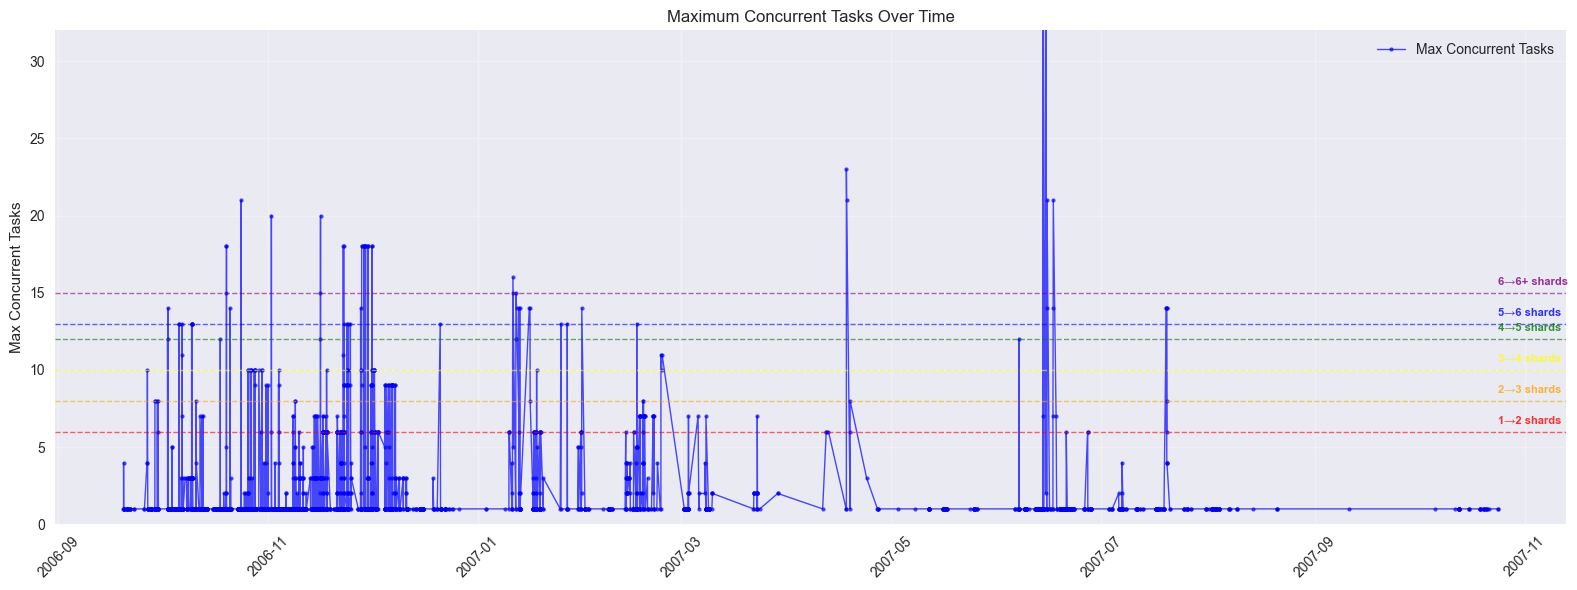

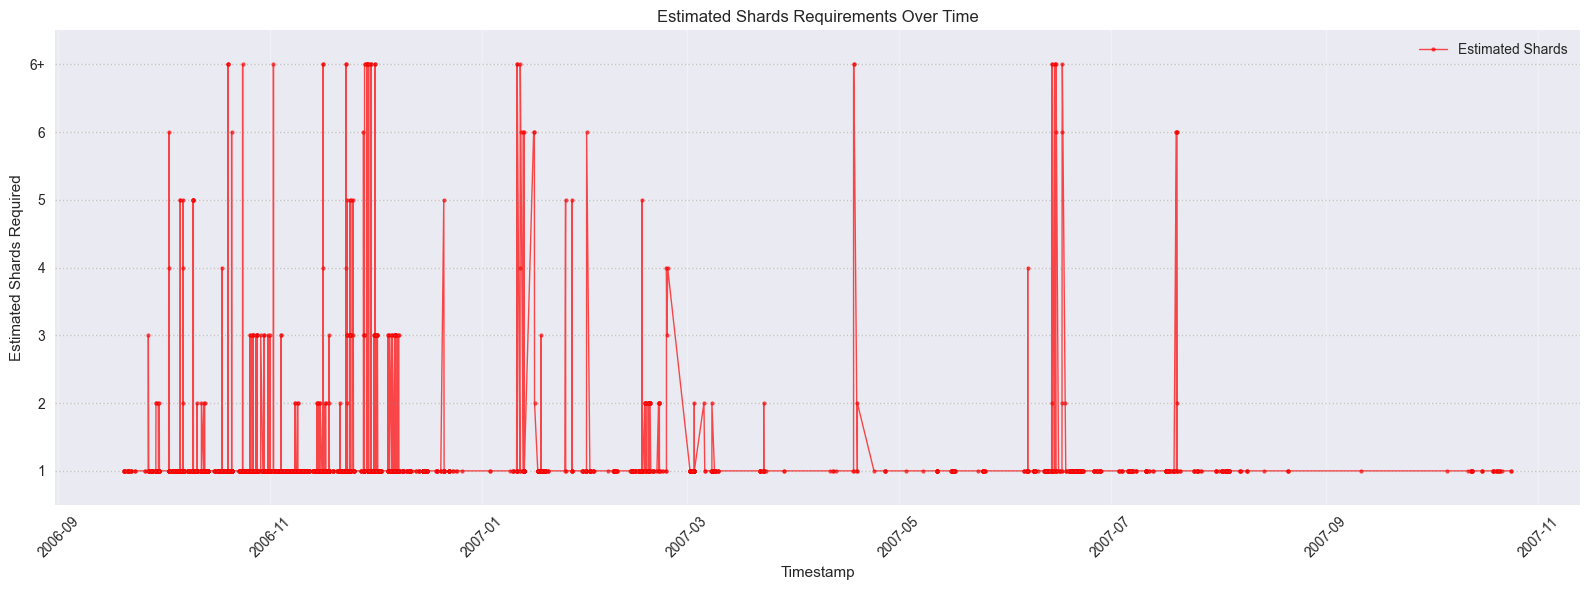


=== TIMELINE STATISTICS ===
----------------------------------------
Total monitoring period: 9580.7 hours
Note: 4 data point(s) above 32 threads cropped from visualization

Concurrency statistics:
• Average concurrent tasks: 1.9
• Peak concurrent tasks: 71
• Minimum concurrent tasks: 1

Sharding requirements:
• 1 shards: 3354 instances (94.4%)
• 2 shards: 57 instances (1.6%)
• 3 shards: 68 instances (1.9%)
• 4 shards: 9 instances (0.3%)
• 5 shards: 16 instances (0.5%)
• 6 shards: 15 instances (0.4%)
• 7+ shards: 33 instances (0.9%)

High concurrency periods (14+ threads):
• Instances: 48
• First occurrence: 2006-10-02 19:47:53.716000
• Last occurrence: 2007-07-19 23:45:50.716000
• Percentage of time: 1.35%


In [32]:
# Plot max_concurrent_tasks and estimated_shards vs timestamp
def plot_concurrency_and_shards_timeline(data):
   """
   Plot max_concurrent_tasks and estimated_shards over time
   """
   
   # Convert timestamp to datetime
   data['ts_submit_dt_parsed'] = pd.to_datetime(data['ts_submit_dt'])
   
   # Sort by timestamp
   data_sorted = data.sort_values('ts_submit_dt_parsed')
   
   # 1. Max concurrent tasks over time
   fig1, ax1 = plt.subplots(1, 1, figsize=(16, 6))
   ax1.plot(data_sorted['ts_submit_dt_parsed'], data_sorted['max_concurrent_tasks'], 
            'o-', color='blue', alpha=0.7, markersize=3, linewidth=1, label='Max Concurrent Tasks')
   ax1.set_ylabel('Max Concurrent Tasks')
   ax1.set_title('Maximum Concurrent Tasks Over Time')
   ax1.grid(True, alpha=0.3)
   ax1.tick_params(axis='x', rotation=45)
   
   # Add horizontal lines for thread range boundaries
   thread_boundaries = [6, 8, 10, 12, 13, 15]  # Changed from 32 to 15
   boundary_labels = ['1→2 shards', '2→3 shards', '3→4 shards', '4→5 shards', '5→6 shards', '6→6+ shards']
   colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
   
   for boundary, label, color in zip(thread_boundaries, boundary_labels, colors):
       ax1.axhline(y=boundary, color=color, linestyle='--', alpha=0.6, linewidth=1)
       ax1.text(data_sorted['ts_submit_dt_parsed'].iloc[-1], boundary + 0.5, 
               label, fontsize=8, alpha=0.8, color=color, fontweight='bold')
   
   ax1.legend()
   ax1.set_ylim(0, 32)  # Crop the y-axis to show data up to 32 threads
   
   plt.tight_layout()
   plt.show()
   
   # 2. Estimated shards over time - LINE PLOT
   fig2, ax2 = plt.subplots(1, 1, figsize=(16, 6))
   
   # Create line plot for estimated shards
   ax2.plot(data_sorted['ts_submit_dt_parsed'], data_sorted['estimated_shards'], 
            'o-', color='red', alpha=0.7, markersize=3, linewidth=1, label='Estimated Shards')
   
   ax2.set_xlabel('Timestamp')
   ax2.set_ylabel('Estimated Shards Required')
   ax2.set_title('Estimated Shards Requirements Over Time')
   ax2.grid(True, alpha=0.3)
   ax2.tick_params(axis='x', rotation=45)
   ax2.legend()
   ax2.set_ylim(0.5, 7.5)
   ax2.set_yticks(range(1, 8))
   ax2.set_yticklabels(['1', '2', '3', '4', '5', '6', '6+'])
   
   # Add horizontal lines for each shard level
   for i in range(1, 8):
       label = f'{i}+ shards' if i == 7 else f'{i} shards'
       ax2.axhline(y=i, color='gray', linestyle=':', alpha=0.4, linewidth=1)
   
   plt.tight_layout()
   plt.show()
   
   # Print timeline statistics
   print("\n=== TIMELINE STATISTICS ===")
   print("-" * 40)
   
   total_duration = (data_sorted['ts_submit_dt_parsed'].max() - 
                    data_sorted['ts_submit_dt_parsed'].min()).total_seconds() / 3600
   print(f"Total monitoring period: {total_duration:.1f} hours")
   
   # Count instances above 32 threads
   above_32_count = (data['max_concurrent_tasks'] > 32).sum()
   if above_32_count > 0:
       print(f"Note: {above_32_count} data point(s) above 32 threads cropped from visualization")
   
   # Statistics by time periods
   print(f"\nConcurrency statistics:")
   print(f"• Average concurrent tasks: {data_sorted['max_concurrent_tasks'].mean():.1f}")
   print(f"• Peak concurrent tasks: {data_sorted['max_concurrent_tasks'].max()}")
   print(f"• Minimum concurrent tasks: {data_sorted['max_concurrent_tasks'].min()}")
   
   print(f"\nSharding requirements:")
   for shard_count in sorted(data_sorted['estimated_shards'].unique()):
       count = (data_sorted['estimated_shards'] == shard_count).sum()
       percentage = (count / len(data_sorted)) * 100
       label = f'{shard_count}+ shards' if shard_count == 7 else f'{shard_count} shards'
       print(f"• {label}: {count} instances ({percentage:.1f}%)")
   
   # Peak periods analysis
   high_concurrency = data_sorted[data_sorted['max_concurrent_tasks'] >= 14]
   if len(high_concurrency) > 0:
       print(f"\nHigh concurrency periods (14+ threads):")
       print(f"• Instances: {len(high_concurrency)}")
       print(f"• First occurrence: {high_concurrency['ts_submit_dt_parsed'].min()}")
       print(f"• Last occurrence: {high_concurrency['ts_submit_dt_parsed'].max()}")
       
       # Time spent in high concurrency
       high_concurrency_percentage = (len(high_concurrency) / len(data_sorted)) * 100
       print(f"• Percentage of time: {high_concurrency_percentage:.2f}%")

# Plot the timeline
plot_concurrency_and_shards_timeline(trace_data_with_shards)

=== SHARDING STRATEGY COST COMPARISON ===
Strategy             Cost per Instance  Total Cost   Threshold Compliance Savings vs Dynamic
------------------------------------------------------------------------------------------
1 Shard (Fixed)      1.0                3552         94.4               % 524               
4 Shards (Fixed)     4.0                14208        98.1               % -10132            
Dynamic Sharding     1.1                4076         99.1               % 0 (baseline)      

=== COST ANALYSIS SUMMARY ===
----------------------------------------
• Total workload instances: 3,552
• Average shards needed (dynamic): 1.15
• Dynamic vs 1 shard: 14.8% MORE expensive
  → Additional cost: 524 units
• Dynamic vs 4 shards: 71.3% savings
  → Cost savings: 10132 units

=== THRESHOLD COMPLIANCE ANALYSIS ===
---------------------------------------------
• 1 Shard: 3354/3552 instances meet thresholds (94.4%)
• 4 Shards: 3483/3552 instances meet thresholds (98.1%)
• Dynamic: 3

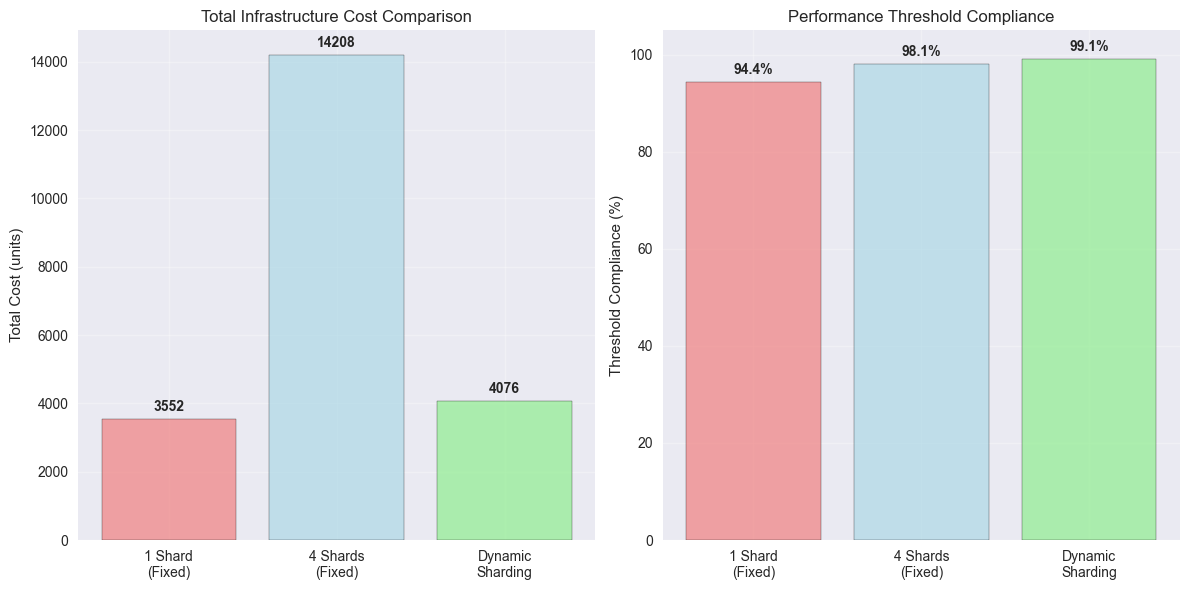


=== PERFORMANCE vs COST TRADE-OFFS ===
---------------------------------------------
1 Shard Strategy:
  ✓ Lowest infrastructure cost
  ✗ Poor performance (94.4% threshold compliance)
  ✗ May not meet SLA requirements for high concurrency

4 Shards Strategy:
  ✓ Good performance for most workloads
  ✓ High threshold compliance (98.1%)
  ✗ Over-provisioning for low concurrency periods
  ✗ 71.3% higher cost than dynamic

Dynamic Sharding Strategy:
  ✓ Optimal resource utilization
  ✓ Excellent threshold compliance (99.1%)
  ✓ Cost-effective across varying workloads
  ✓ Scales with actual demand
  ✗ Requires dynamic scaling capability


In [33]:
# Cost comparison between different sharding strategies
def cost_comparison_analysis(data):
   """
   Perform cost comparison between 1 shard, 4 shards, and dynamic sharding
   """
   
   print("=== SHARDING STRATEGY COST COMPARISON ===")
   print("=" * 60)
   
   # Define cost assumptions (relative units)
   cost_per_shard = 1.0  # Base cost unit per shard
   total_instances = len(data)
   
   # Strategy 1: Always 1 shard (unsharded)
   strategy_1_cost = 1 * cost_per_shard
   strategy_1_total_cost = strategy_1_cost * total_instances
   
   # Strategy 2: Always 4 shards (fixed sharding)
   strategy_2_cost = 4 * cost_per_shard
   strategy_2_total_cost = strategy_2_cost * total_instances
   
   # Strategy 3: Dynamic sharding (based on actual requirements)
   dynamic_costs = []
   for _, row in data.iterrows():
       required_shards = row['estimated_shards']
       if required_shards == 7:  # 6+ shards, assume 6 for cost calculation
           required_shards = 6
       dynamic_costs.append(required_shards * cost_per_shard)
   
   strategy_3_total_cost = sum(dynamic_costs)
   strategy_3_avg_cost = strategy_3_total_cost / total_instances
   
   # Calculate threshold compliance percentages
   # Based on the thread ranges and sharding strategy analysis:
   # 1 shard can handle: 1-6 threads for standard queries (200ms), 1-6 threads for aggregation (500ms)
   # 4 shards can handle: 1-11 threads for standard queries, 1-12+ threads for aggregation
   # Dynamic sharding: optimal for each workload
   
   # Strategy 1 (1 shard) compliance
   strategy_1_compliant = (data['max_concurrent_tasks'] <= 6).sum()
   strategy_1_compliance_pct = (strategy_1_compliant / total_instances) * 100
   
   # Strategy 2 (4 shards) compliance
   # 4 shards can handle up to ~11 threads for standard queries, ~12+ for aggregation
   # Being conservative, assume it handles up to 11 threads well
   strategy_2_compliant = (data['max_concurrent_tasks'] <= 11).sum()
   strategy_2_compliance_pct = (strategy_2_compliant / total_instances) * 100
   
   # Strategy 3 (dynamic) compliance
   # Dynamic sharding is designed to meet thresholds optimally
   # Instances requiring 1-6 shards should meet thresholds
   # Only 6+ shards (estimated_shards == 7) may exceed thresholds
   strategy_3_compliant = (data['estimated_shards'] <= 6).sum()
   strategy_3_compliance_pct = (strategy_3_compliant / total_instances) * 100
   
   # Calculate savings
   savings_vs_1_shard = strategy_1_total_cost - strategy_3_total_cost
   savings_vs_4_shards = strategy_2_total_cost - strategy_3_total_cost
   
   savings_pct_vs_1_shard = (savings_vs_1_shard / strategy_1_total_cost) * 100
   savings_pct_vs_4_shards = (savings_vs_4_shards / strategy_2_total_cost) * 100
   
   # Print comparison table
   print(f"{'Strategy':<20} {'Cost per Instance':<18} {'Total Cost':<12} {'Threshold Compliance':<20} {'Savings vs Dynamic':<18}")
   print("-" * 90)
   print(f"{'1 Shard (Fixed)':<20} {strategy_1_cost:<18.1f} {strategy_1_total_cost:<12.0f} {strategy_1_compliance_pct:<19.1f}% {-savings_vs_1_shard:<18.0f}")
   print(f"{'4 Shards (Fixed)':<20} {strategy_2_cost:<18.1f} {strategy_2_total_cost:<12.0f} {strategy_2_compliance_pct:<19.1f}% {-savings_vs_4_shards:<18.0f}")
   print(f"{'Dynamic Sharding':<20} {strategy_3_avg_cost:<18.1f} {strategy_3_total_cost:<12.0f} {strategy_3_compliance_pct:<19.1f}% {'0 (baseline)':<18}")
   
   print(f"\n=== COST ANALYSIS SUMMARY ===")
   print("-" * 40)
   print(f"• Total workload instances: {total_instances:,}")
   print(f"• Average shards needed (dynamic): {strategy_3_avg_cost:.2f}")
   
   if savings_vs_1_shard < 0:  # Dynamic costs more than 1 shard
       print(f"• Dynamic vs 1 shard: {abs(savings_pct_vs_1_shard):.1f}% MORE expensive")
       print(f"  → Additional cost: {abs(savings_vs_1_shard):.0f} units")
   else:
       print(f"• Dynamic vs 1 shard: {savings_pct_vs_1_shard:.1f}% savings")
       print(f"  → Cost savings: {savings_vs_1_shard:.0f} units")
   
   if savings_vs_4_shards < 0:  # Dynamic costs more than 4 shards
       print(f"• Dynamic vs 4 shards: {abs(savings_pct_vs_4_shards):.1f}% MORE expensive")
       print(f"  → Additional cost: {abs(savings_vs_4_shards):.0f} units")
   else:
       print(f"• Dynamic vs 4 shards: {savings_pct_vs_4_shards:.1f}% savings")
       print(f"  → Cost savings: {savings_vs_4_shards:.0f} units")
   
   print(f"\n=== THRESHOLD COMPLIANCE ANALYSIS ===")
   print("-" * 45)
   print(f"• 1 Shard: {strategy_1_compliant}/{total_instances} instances meet thresholds ({strategy_1_compliance_pct:.1f}%)")
   print(f"• 4 Shards: {strategy_2_compliant}/{total_instances} instances meet thresholds ({strategy_2_compliance_pct:.1f}%)")
   print(f"• Dynamic: {strategy_3_compliant}/{total_instances} instances meet thresholds ({strategy_3_compliance_pct:.1f}%)")
   
   # Create visualization
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
   
   # Bar chart comparing total costs
   strategies = ['1 Shard\n(Fixed)', '4 Shards\n(Fixed)', 'Dynamic\nSharding']
   total_costs = [strategy_1_total_cost, strategy_2_total_cost, strategy_3_total_cost]
   colors = ['lightcoral', 'lightblue', 'lightgreen']
   
   bars1 = ax1.bar(strategies, total_costs, color=colors, alpha=0.7, edgecolor='black')
   ax1.set_ylabel('Total Cost (units)')
   ax1.set_title('Total Infrastructure Cost Comparison')
   ax1.grid(True, alpha=0.3)
   
   # Add value labels on bars
   for bar, cost in zip(bars1, total_costs):
       ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_costs)*0.01, 
               f'{cost:.0f}', ha='center', va='bottom', fontweight='bold')
   
   # Bar chart comparing threshold compliance
   compliance_pcts = [strategy_1_compliance_pct, strategy_2_compliance_pct, strategy_3_compliance_pct]
   bars2 = ax2.bar(strategies, compliance_pcts, color=colors, alpha=0.7, edgecolor='black')
   ax2.set_ylabel('Threshold Compliance (%)')
   ax2.set_title('Performance Threshold Compliance')
   ax2.set_ylim(0, 105)  # Give more space at the top
   ax2.grid(True, alpha=0.3)
   
   # Add value labels on bars with better positioning
   for bar, pct in zip(bars2, compliance_pcts):
       ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
               f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
   
   plt.tight_layout()
   plt.show()
   
   # Performance vs Cost trade-offs
   print(f"\n=== PERFORMANCE vs COST TRADE-OFFS ===")
   print("-" * 45)
   print("1 Shard Strategy:")
   print("  ✓ Lowest infrastructure cost")
   print(f"  ✗ Poor performance ({strategy_1_compliance_pct:.1f}% threshold compliance)")
   print("  ✗ May not meet SLA requirements for high concurrency")
   
   print("\n4 Shards Strategy:")
   print("  ✓ Good performance for most workloads")
   print(f"  ✓ High threshold compliance ({strategy_2_compliance_pct:.1f}%)")
   print("  ✗ Over-provisioning for low concurrency periods")
   print(f"  ✗ {abs(savings_pct_vs_4_shards):.1f}% higher cost than dynamic")
   
   print("\nDynamic Sharding Strategy:")
   print("  ✓ Optimal resource utilization")
   print(f"  ✓ Excellent threshold compliance ({strategy_3_compliance_pct:.1f}%)")
   print("  ✓ Cost-effective across varying workloads")
   print("  ✓ Scales with actual demand")
   print("  ✗ Requires dynamic scaling capability")
   
   return {
       'strategy_1_cost': strategy_1_total_cost,
       'strategy_2_cost': strategy_2_total_cost,
       'strategy_3_cost': strategy_3_total_cost,
       'strategy_1_compliance': strategy_1_compliance_pct,
       'strategy_2_compliance': strategy_2_compliance_pct,
       'strategy_3_compliance': strategy_3_compliance_pct,
       'dynamic_avg_shards': strategy_3_avg_cost,
       'savings_vs_4_shards': savings_vs_4_shards,
       'savings_pct_vs_4_shards': savings_pct_vs_4_shards
   }

# Run cost comparison
cost_results = cost_comparison_analysis(trace_data_with_shards)